# Fine Tunning LM with BatchAllTripletLoss

* Used **BatchAllTripletLoss**, loss function which takes a batch with (sentence, label) pairs and computes the loss for all possible, valid triplets, i.e., anchor and positive must have the same label, anchor and negative a different label. The labels must be integers, with same label indicating sentences from the same class. Train dataset must contain at least 2 examples per label class.

* The goal of the triplet loss is to make sure that:

    * Two examples with the same label have their embeddings close together in the embedding space
    * Two examples with different labels have their embeddings far away.


* Used the train set to fine tune the models on it. Then save use the model to get embeddings of the model and then evaluate the model with **MolEval**.

* The BatchAllTripletLoss works well when the dataset is a single task dataset.Hence for the multi task datasets, encoded their labels into one to fine tune and then evaluated them based on the



Ref:
* [Sentence Transformer](https://sbert.net/docs/package_reference/sentence_transformer/losses.html#batchalltripletloss)
* [Blog](https://omoindrot.github.io/triplet-loss)
* [Paper](https://openaccess.thecvf.com/content_CVPRW_2020/papers/w22/Yuan_In_Defense_of_the_Triplet_Loss_Again_Learning_Robust_Person_CVPRW_2020_paper.pdf)





**Results:**

| Model      | BBBP           | BACE           | HIV            | ClinTox        | SIDER          | Tox21          |
|------------|----------------|----------------|----------------|----------------|----------------|----------------|
| **#Tasks** | 1              | 1              | 1              | 2              | 27             | 12             |
| **BERT**   | 0.947 ± 0.007  | 0.845 ± 0.016  | 0.780 ± 0.011  | 0.983 ± 0.017  | **0.625 ± 0.014**  | **0.786 ± 0.011**  |
| **BERT-FT**| **0.963 ± 0.010**  | **0.865 ± 0.011**  | **0.878 ± 0.006**  | 0.997 ± 0.002  | 0.616 ± 0.013  | 0.750 ± 0.012  |
| **Roberta**| 0.939 ± 0.008  | 0.837 ± 0.015  | 0.769 ± 0.016  | 0.837 ± 0.015  | 0.621 ± 0.005  | 0.773 ± 0.009  |
| **Roberta_FT** | 0.953 ± 0.004 | 0.860 ± 0.021 | 0.726 ± 0.018 | **0.998 ± 0.000** | 0.622 ± 0.011 | 0.748 ± 0.010 |


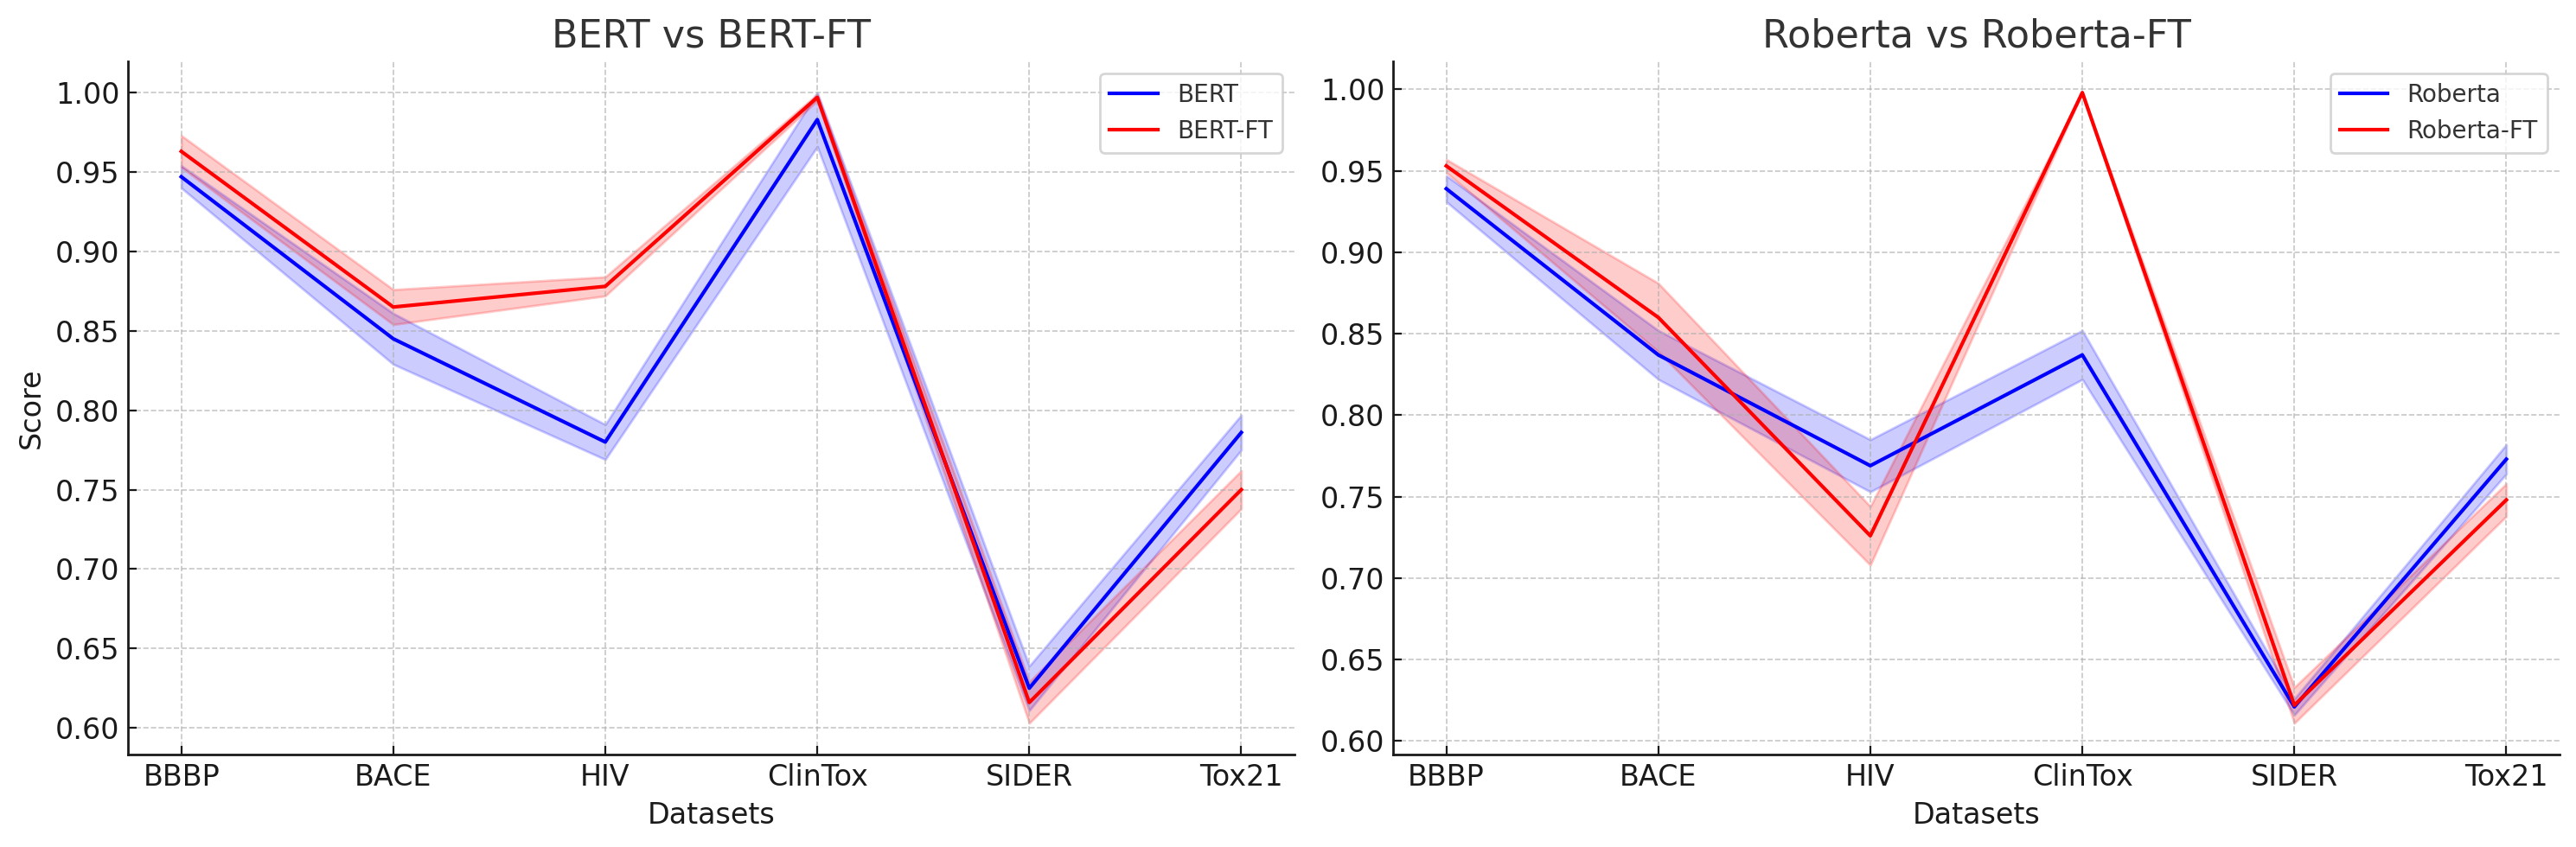


In [ ]:
%pip install sentence-transformers
!git clone https://github.com/sshaghayeghs/MolEval
!cd MolEval
%pip install torch transformers pandas numpy tqdm openai deepchem rdkit networkx matplotlib
%pip install datasets

  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl.metadata (1.8 kB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-manylinu

## BERT

In [ ]:
import pandas as pd
from sentence_transformers import SentenceTransformer, InputExample, losses, models
from torch.utils.data import DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from MolEval.MolRead import load_dataset
from MolEval.MolEval import evaluate_classification
import numpy as np
from transformers import BertTokenizer

# Define the datasets and their corresponding task types
datasets = {
    'bbbp': 'Classification',
    'bace_classification': 'Classification',
    'hiv': 'Classification',
    'tox21': 'MultitaskClassification',
    'clintox': 'MultitaskClassification',
    'sider': 'MultitaskClassification',
}

# Function to select top PCA labels
def select_top_pca_labels(df, label_columns, top_n=3):
    X = df[label_columns]
    pca = PCA(n_components=1)
    pca.fit(X)
    loadings = np.abs(pca.components_[0])
    top_indices = loadings.argsort()[::-1][:top_n]
    top_labels = X.columns[top_indices].tolist()
    return top_labels

# Function to encode multi-labels into a single integer class
def encode_combination(df, label_columns, smiles_column='SMILES'):
    df['combined_label'] = df[label_columns].apply(lambda x: '-'.join(map(str, x)), axis=1)
    label_encoder = LabelEncoder()
    df['label'] = label_encoder.fit_transform(df['combined_label'])
    df = df.drop(columns=['combined_label'])
    return df[[smiles_column, 'label']]

# Prepare the dataset based on task type
def prepare_dataset(df, task_type):
    label_columns = select_top_pca_labels(df, label_columns=df.columns.difference(['SMILES']).tolist(), top_n=2)
    df = encode_combination(df, label_columns)
    return df

# Train the model based on task type
def train_model(train, task_type):
    model_name = "FacebookAI/roberta-base"
    word_embedding_model = models.Transformer(model_name, max_seq_length=512)
    pooling_model = models.Pooling(word_embedding_model.get_word_embedding_dimension(),
                                   pooling_mode_cls_token=True,
                                   pooling_mode_mean_tokens=False,
                                   pooling_mode_max_tokens=False)
    model = SentenceTransformer(modules=[word_embedding_model, pooling_model])

    data_dict = {
        "sentence": train['SMILES'].tolist(),
        "label": train['label'].tolist() if task_type == 'MultitaskClassification' else train.drop(['SMILES'], axis=1).values.tolist()
    }

    train_examples = [InputExample(texts=[sentence], label=label) for sentence, label in zip(data_dict['sentence'], data_dict['label'])]
    train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=32)

    loss = losses.BatchAllTripletLoss(model=model)


    model.fit(train_objectives=[(train_dataloader, loss)], epochs=10, warmup_steps=100)

    return model

# Evaluate the model based on task type
def evaluate_model(model, df, task_type):
    embeddings = model.encode(df['SMILES'].tolist(), show_progress_bar=True)
    targets = df.drop(columns=['SMILES']).to_numpy()

    if task_type == 'Classification' or task_type == 'MultitaskClassification':
        f1_score, f1_score_std, AUROC, AUROC_std = evaluate_classification(features=embeddings, targets=targets, n_splits=5, task=task_type)
        print(f'F1 score: {f1_score:.4f} +/- {f1_score_std:.4f}')
        print(f'AUROC: {AUROC:.4f} +/- {AUROC_std:.4f}')

# Main loop to process each dataset
for dataset_name, task_type in datasets.items():
    print(f'Processing dataset: {dataset_name} for task: {task_type}')

    # Load and prepare the training dataset
    train, valid, test = load_dataset(dataset_name, split=True)
    if task_type == 'MultitaskClassification':
      train = prepare_dataset(train, task_type)

    # Train the model
    model = train_model(train, task_type)

    # Load the full dataset (for evaluation)
    df = load_dataset(dataset_name, split=False)

    # Evaluate the model
    evaluate_model(model, df, task_type)

    # Clean up the model to free memory
    del model
    del train
    del df

    print('--------------------------------------------------')


Processing dataset: bbbp for task: Classification


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at FacebookAI/roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

...

F1 score: 0.9722 +/- 0.0153
AUROC: 0.9984 +/- 0.0008
--------------------------------------------------
Processing dataset: sider for task: MultitaskClassification


Some weights of RobertaModel were not initialized from the model checkpoint at FacebookAI/roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss


Batches:   0%|          | 0/45 [00:00<?, ?it/s]

F1 score: 0.6237 +/- 0.0090
AUROC: 0.6229 +/- 0.0110
--------------------------------------------------


## RoBERTa

In [ ]:
import pandas as pd
from sentence_transformers import SentenceTransformer, InputExample, losses, models
from torch.utils.data import DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from MolEval.MolRead import load_dataset
from MolEval.MolEval import evaluate_classification
import numpy as np
from transformers import BertTokenizer

# Define the datasets and their corresponding task types
datasets = {
    'bbbp': 'Classification',
    'bace_classification': 'Classification',
    'hiv': 'Classification',
    'tox21': 'MultitaskClassification',
    'clintox': 'MultitaskClassification',
    'sider': 'MultitaskClassification',
}

# Function to select top PCA labels
def select_top_pca_labels(df, label_columns, top_n=3):
    X = df[label_columns]
    pca = PCA(n_components=1)
    pca.fit(X)
    loadings = np.abs(pca.components_[0])
    top_indices = loadings.argsort()[::-1][:top_n]
    top_labels = X.columns[top_indices].tolist()
    return top_labels

# Function to encode multi-labels into a single integer class
def encode_combination(df, label_columns, smiles_column='SMILES'):
    df['combined_label'] = df[label_columns].apply(lambda x: '-'.join(map(str, x)), axis=1)
    label_encoder = LabelEncoder()
    df['label'] = label_encoder.fit_transform(df['combined_label'])
    df = df.drop(columns=['combined_label'])
    return df[[smiles_column, 'label']]

# Prepare the dataset based on task type
def prepare_dataset(df, task_type):
    label_columns = select_top_pca_labels(df, label_columns=df.columns.difference(['SMILES']).tolist(), top_n=2)
    df = encode_combination(df, label_columns)
    return df

# Train the model based on task type
def train_model(train, task_type):
    model_name = "bert-base-uncased"
    word_embedding_model = models.Transformer(model_name, max_seq_length=512)
    pooling_model = models.Pooling(word_embedding_model.get_word_embedding_dimension(),
                                   pooling_mode_cls_token=True,
                                   pooling_mode_mean_tokens=False,
                                   pooling_mode_max_tokens=False)
    model = SentenceTransformer(modules=[word_embedding_model, pooling_model])

    data_dict = {
        "sentence": train['SMILES'].tolist(),
        "label": train['label'].tolist() if task_type == 'MultitaskClassification' else train.drop(['SMILES'], axis=1).values.tolist()
    }

    train_examples = [InputExample(texts=[sentence], label=label) for sentence, label in zip(data_dict['sentence'], data_dict['label'])]
    train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=32)

    loss = losses.BatchAllTripletLoss(model=model)


    model.fit(train_objectives=[(train_dataloader, loss)], epochs=10, warmup_steps=100)

    return model

# Evaluate the model based on task type
def evaluate_model(model, df, task_type):
    embeddings = model.encode(df['SMILES'].tolist(), show_progress_bar=True)
    targets = df.drop(columns=['SMILES']).to_numpy()

    if task_type == 'Classification' or task_type == 'MultitaskClassification':
        f1_score, f1_score_std, AUROC, AUROC_std = evaluate_classification(features=embeddings, targets=targets, n_splits=5, task=task_type)
        print(f'F1 score: {f1_score:.4f} +/- {f1_score_std:.4f}')
        print(f'AUROC: {AUROC:.4f} +/- {AUROC_std:.4f}')

# Main loop to process each dataset
for dataset_name, task_type in datasets.items():
    print(f'Processing dataset: {dataset_name} for task: {task_type}')

    # Load and prepare the training dataset
    train, valid, test = load_dataset(dataset_name, split=True)
    if task_type == 'MultitaskClassification':
      train = prepare_dataset(train, task_type)

    # Train the model
    model = train_model(train, task_type)

    # Load the full dataset (for evaluation)
    df = load_dataset(dataset_name, split=False)

    # Evaluate the model
    evaluate_model(model, df, task_type)

    # Clean up the model to free memory
    del model
    del train
    del df

    print('--------------------------------------------------')


Processing dataset: bbbp for task: Classification


[17:27:20] Explicit valence for atom # 1 N, 4, is greater than permitted
[17:27:20] WARNING: not removing hydrogen atom without neighbors
[17:27:20] Explicit valence for atom # 6 N, 4, is greater than permitted
[17:27:20] WARNING: not removing hydrogen atom without neighbors
[17:27:20] WARNING: not removing hydrogen atom without neighbors
[17:27:20] WARNING: not removing hydrogen atom without neighbors
[17:27:20] WARNING: not removing hydrogen atom without neighbors
[17:27:20] WARNING: not removing hydrogen atom without neighbors
[17:27:20] WARNING: not removing hydrogen atom without neighbors
[17:27:20] Explicit valence for atom # 6 N, 4, is greater than permitted
[17:27:20] WARNING: not removing hydrogen atom without neighbors
[17:27:20] WARNING: not removing hydrogen atom without neighbors
[17:27:20] WARNING: not removing hydrogen atom without neighbors
[17:27:20] WARNING: not removing hydrogen atom without neighbors
[17:27:20] Explicit valence for atom # 11 N, 4, is greater than pe

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/47 [00:00<?, ?it/s]

F1 score: 0.9767 +/- 0.0103
AUROC: 0.9976 +/- 0.0024
--------------------------------------------------
Processing dataset: sider for task: MultitaskClassification


Step,Training Loss


Batches:   0%|          | 0/45 [00:00<?, ?it/s]

F1 score: 0.6237 +/- 0.0086
AUROC: 0.6166 +/- 0.0136
--------------------------------------------------
